### Importação dos dados



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from cycler import cycler

paleta = plt.get_cmap('Paired').colors
ciclo_cores = cycler('color', paleta)
plt.rc('axes', prop_cycle=ciclo_cores)

#1. Análise do faturamento



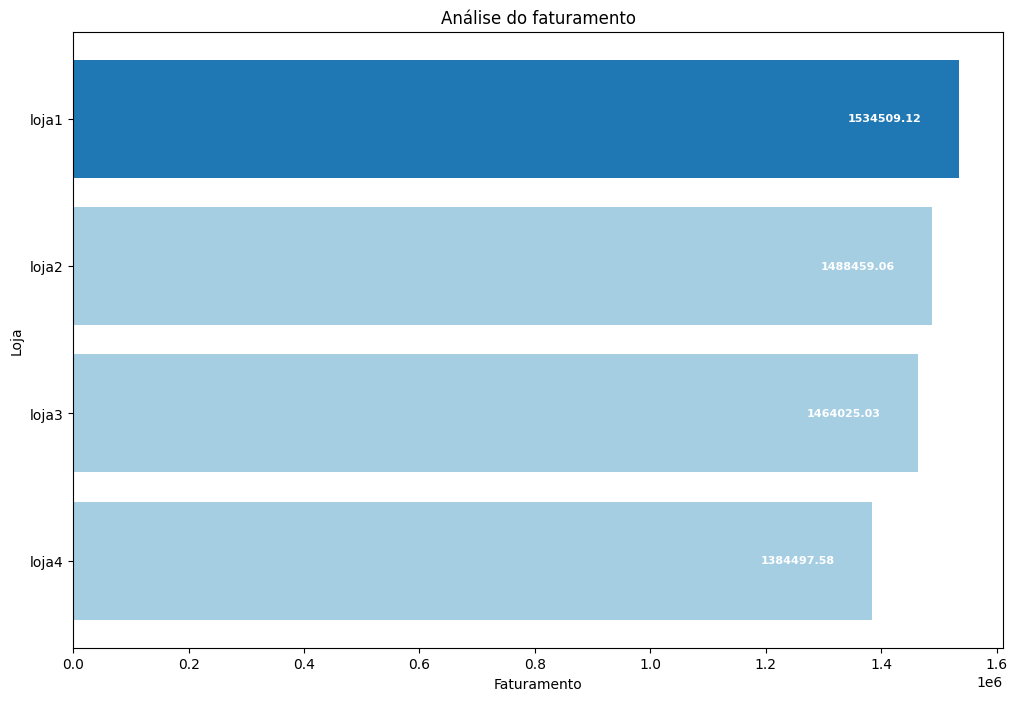

In [4]:
faturamento_loja1 = loja['Preço'].sum()
faturamento_loja2 = loja2['Preço'].sum()
faturamento_loja3 = loja3['Preço'].sum()
faturamento_loja4 = loja4['Preço'].sum()
lojas = ['loja1', 'loja2', 'loja3', 'loja4']
faturamento_lojas = [faturamento_loja1, faturamento_loja2, faturamento_loja3, faturamento_loja4]

plt.figure(figsize=(12, 8))

x = [paleta[1] if v == max(faturamento_lojas) else paleta[0] for v in faturamento_lojas]
faturamento = plt.barh(lojas, faturamento_lojas, color = x)
plt.bar_label(faturamento, faturamento_lojas, weight = 'bold', fontsize = 8, padding = -80, color = 'white')
plt.xlabel('Faturamento')
plt.ylabel('Loja')
plt.title('Análise do faturamento')
plt.gca().invert_yaxis()
plt.show()

# 2. Vendas por Categoria

In [13]:
categoria_counts_loja1 = loja['Categoria do Produto'].value_counts()
categoria_counts_loja2 = loja2['Categoria do Produto'].value_counts()
categoria_counts_loja3 = loja3['Categoria do Produto'].value_counts()
categoria_counts_loja4 = loja4['Categoria do Produto'].value_counts()



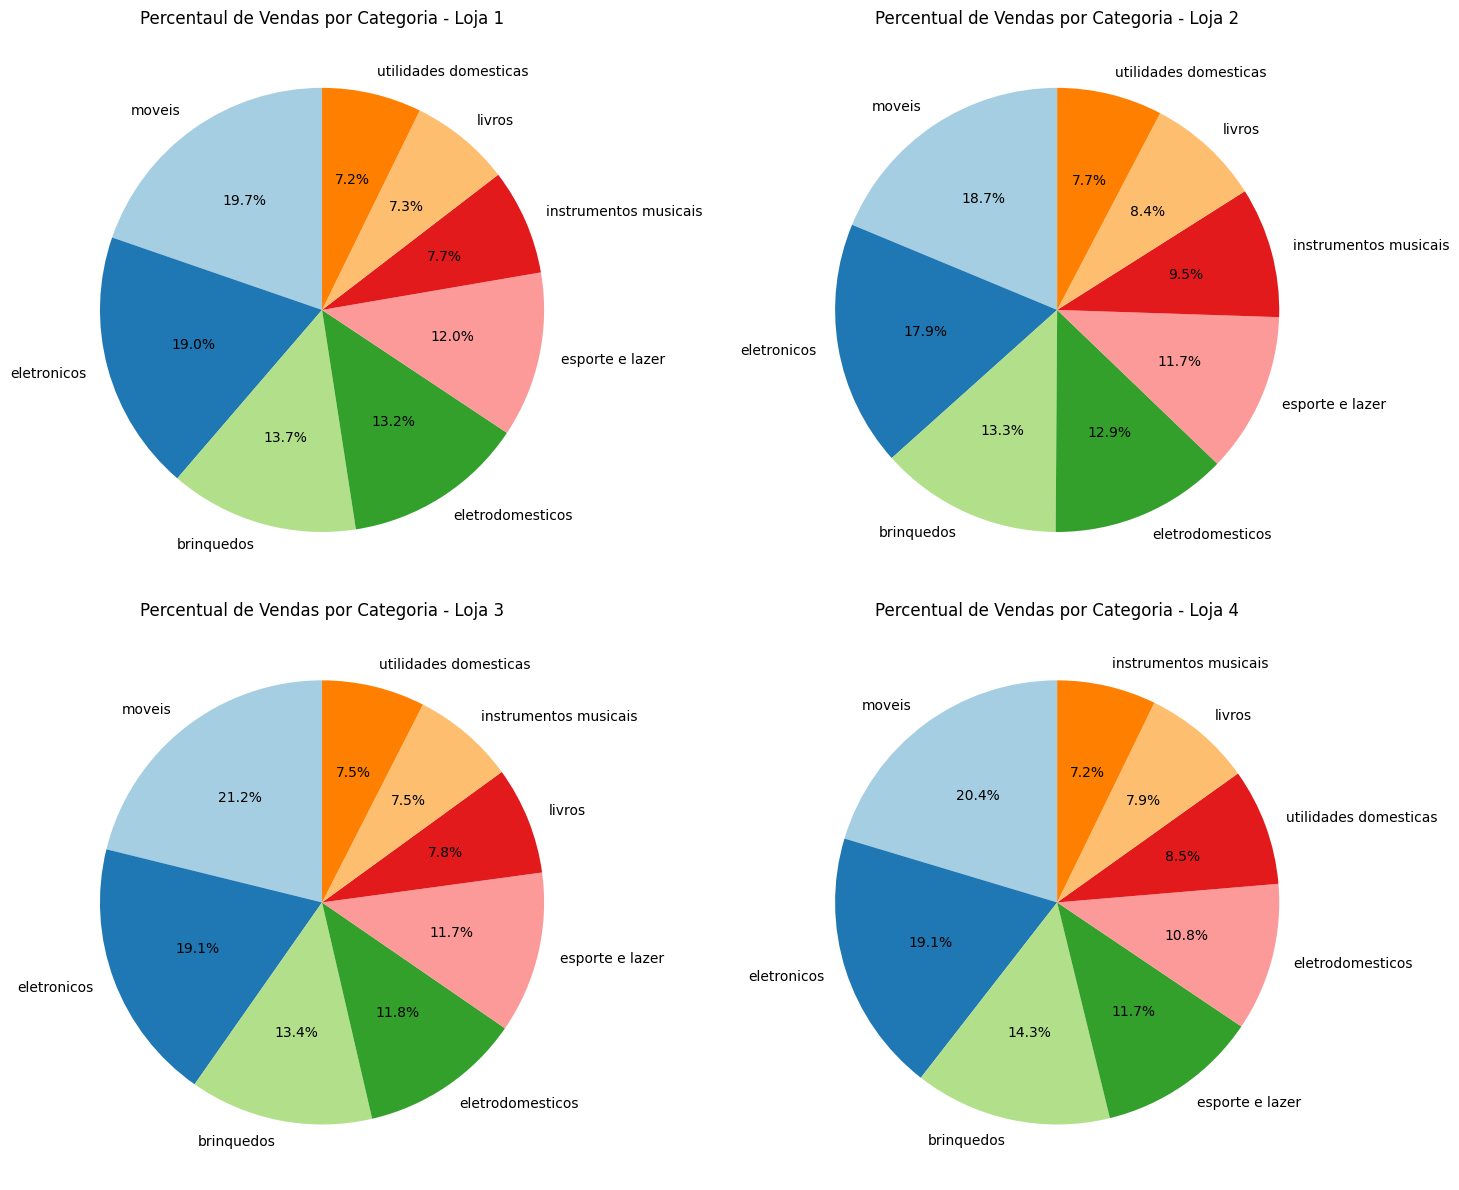

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

axs[0, 0].pie(categoria_counts_loja1, labels=categoria_counts_loja1.index, autopct='%1.1f%%', startangle=90)
axs[0, 0].set_title('Percentaul de Vendas por Categoria - Loja 1')

axs[0, 1].pie(categoria_counts_loja2, labels=categoria_counts_loja2.index, autopct='%1.1f%%', startangle=90)
axs[0, 1].set_title('Percentual de Vendas por Categoria - Loja 2')

axs[1, 0].pie(categoria_counts_loja3, labels=categoria_counts_loja3.index, autopct='%1.1f%%', startangle=90)
axs[1, 0].set_title('Percentual de Vendas por Categoria - Loja 3')

axs[1, 1].pie(categoria_counts_loja4, labels=categoria_counts_loja4.index, autopct='%1.1f%%', startangle=90)
axs[1, 1].set_title('Percentual de Vendas por Categoria - Loja 4')

plt.tight_layout()
plt.show()

# 3. Média de Avaliação das Lojas


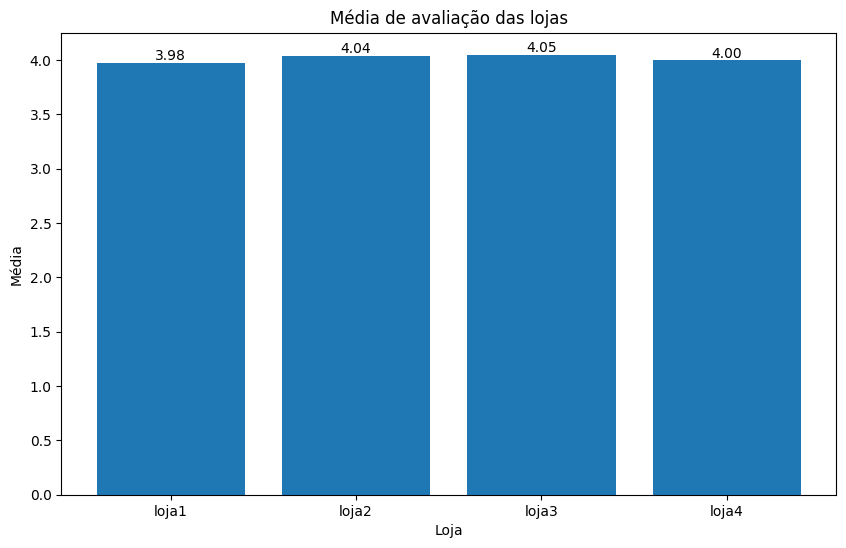

In [76]:
media_loja1 = loja['Avaliação da compra'].mean()
media_loja2 = loja2['Avaliação da compra'].mean()
media_loja3 = loja3['Avaliação da compra'].mean()
media_loja4 = loja4['Avaliação da compra'].mean()



media_lojas = [media_loja1, media_loja2, media_loja3, media_loja4]

lojas = ['loja1', 'loja2', 'loja3', 'loja4']

plt.figure(figsize=(10, 6))
medias = plt.bar(lojas, media_lojas, color = paleta[1])
plt.bar_label(medias, [f'{m:.2f}' for m in media_lojas])
plt.title('Média de avaliação das lojas')
plt.xlabel('Loja')
plt.ylabel('Média')
plt.show()

# 4. Produtos Mais e Menos Vendidos

In [63]:
prods_loja1 = loja['Produto'].value_counts()
prods_loja2 = loja2['Produto'].value_counts()
prods_loja3 = loja3['Produto'].value_counts()
prods_loja4 = loja4['Produto'].value_counts()

In [69]:
mais_vendidos_l1 = prods_loja1.head(5).index.to_list()
menos_vendidos_l1 = prods_loja1.tail(5).index.to_list()
produtos_exibidos_l1 = mais_vendidos_l1 + menos_vendidos_l1

mais_vendidos_l2 = prods_loja2.head(5).index.to_list()
menos_vendidos_l2 = prods_loja2.tail(5).index.to_list()
produtos_exibidos_l2 = mais_vendidos_l2 + menos_vendidos_l2

mais_vendidos_l3 = prods_loja3.head(5).index.to_list()
menos_vendidos_l3 = prods_loja3.tail(5).index.to_list()
produtos_exibidos_l3 = mais_vendidos_l3 + menos_vendidos_l3


mais_vendidos_l4 = prods_loja4.head(5).index.to_list()
menos_vendidos_l4 = prods_loja4.tail(5).index.to_list()
produtos_exibidos_l4 = mais_vendidos_l4 + menos_vendidos_l4


/tmp/ipython-input-258770092.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = loja, x = 'Produto', order = produtos_exibidos_l1, palette = 'Paired', ax = axs[0,0])
/tmp/ipython-input-258770092.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = loja2, x = 'Produto', order = produtos_exibidos_l2, palette = 'Paired', ax = axs[0,1])
/tmp/ipython-input-258770092.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = loja3, x = 'Produto', order = produtos_exibidos_l3, palette = 'Paired', ax = axs[1,0])
/tmp/ipython-in

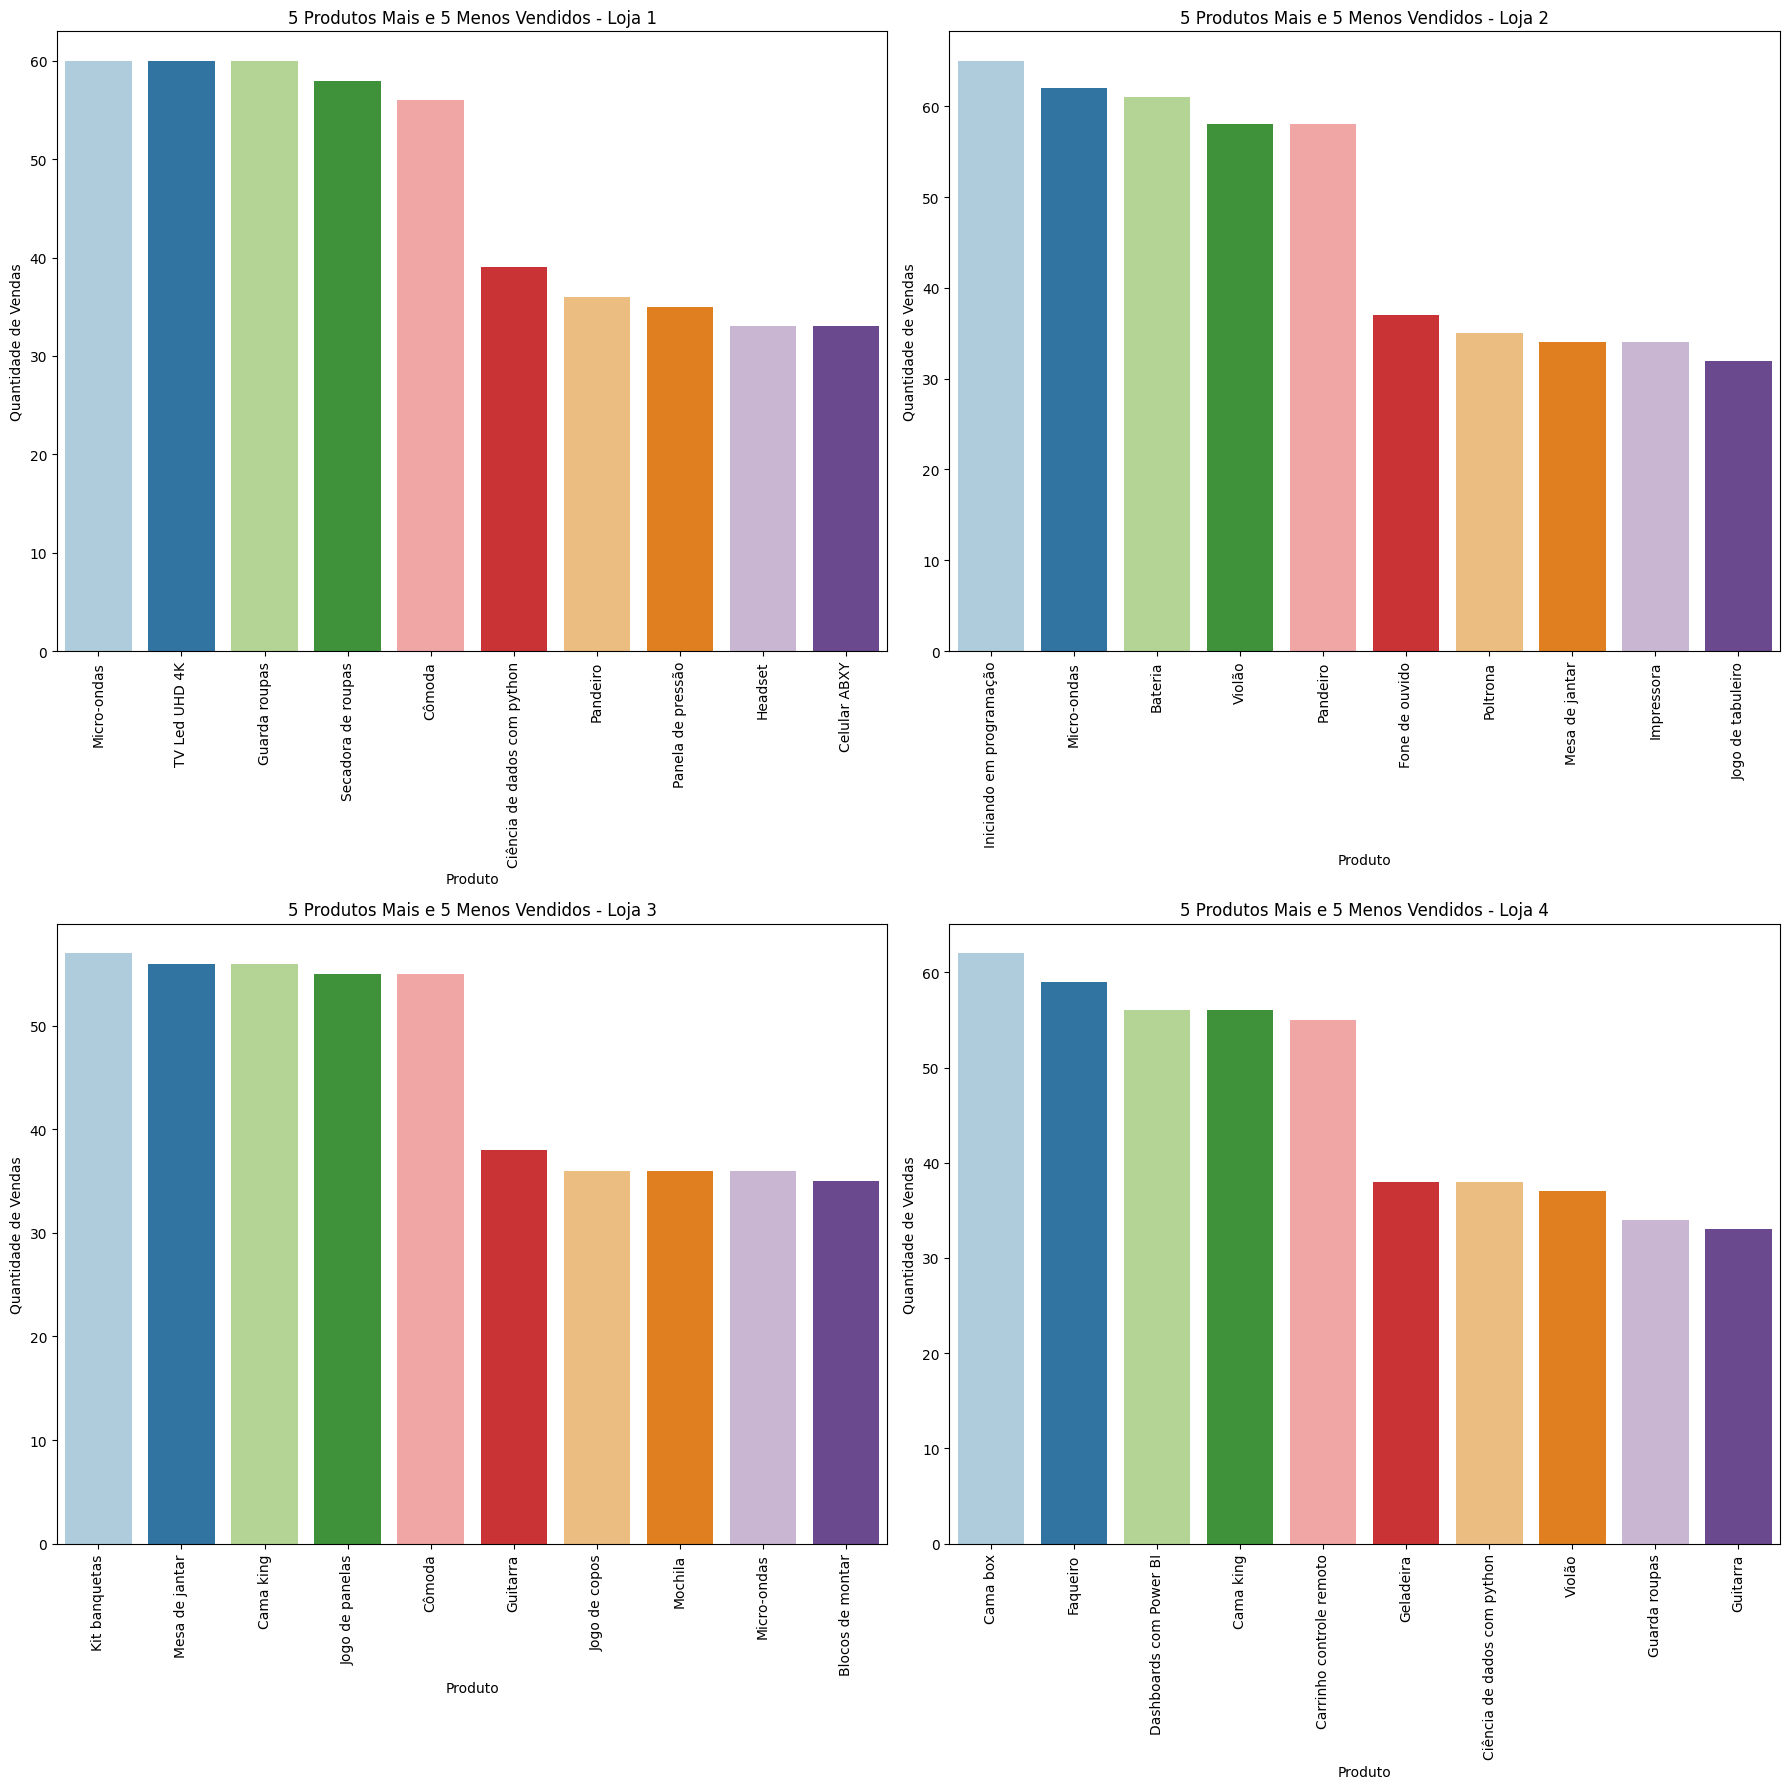

In [70]:
fig, axs = plt.subplots(2, 2)
fig.set_size_inches(18, 18)

# Loja 1:

sns.countplot(data = loja, x = 'Produto', order = produtos_exibidos_l1, palette = 'Paired', ax = axs[0,0])
axs[0,0].set_title('5 Produtos Mais e 5 Menos Vendidos - Loja 1')
axs[0,0].set_xlabel('Produto')
axs[0,0].set_ylabel('Quantidade de Vendas')
axs[0,0].tick_params(axis = 'x', rotation=90)

# Loja 2:

sns.countplot(data = loja2, x = 'Produto', order = produtos_exibidos_l2, palette = 'Paired', ax = axs[0,1])
axs[0,1].set_title('5 Produtos Mais e 5 Menos Vendidos - Loja 2')
axs[0,1].set_xlabel('Produto')
axs[0,1].set_ylabel('Quantidade de Vendas')
axs[0,1].tick_params(axis = 'x', rotation=90)

# Loja 3:

sns.countplot(data = loja3, x = 'Produto', order = produtos_exibidos_l3, palette = 'Paired', ax = axs[1,0])
axs[1,0].set_title('5 Produtos Mais e 5 Menos Vendidos - Loja 3')
axs[1,0].set_xlabel('Produto')
axs[1,0].set_ylabel('Quantidade de Vendas')
axs[1,0].tick_params(axis = 'x', rotation=90)

#Loja 4:

sns.countplot(data = loja4, x = 'Produto', order = produtos_exibidos_l4, palette = 'Paired', ax = axs[1,1])
axs[1,1].set_title('5 Produtos Mais e 5 Menos Vendidos - Loja 4')
axs[1,1].set_xlabel('Produto')
axs[1,1].set_ylabel('Quantidade de Vendas')
axs[1,1].tick_params(axis = 'x', rotation=90)

plt.tight_layout()
plt.show()


# 5. Frete Médio por Loja

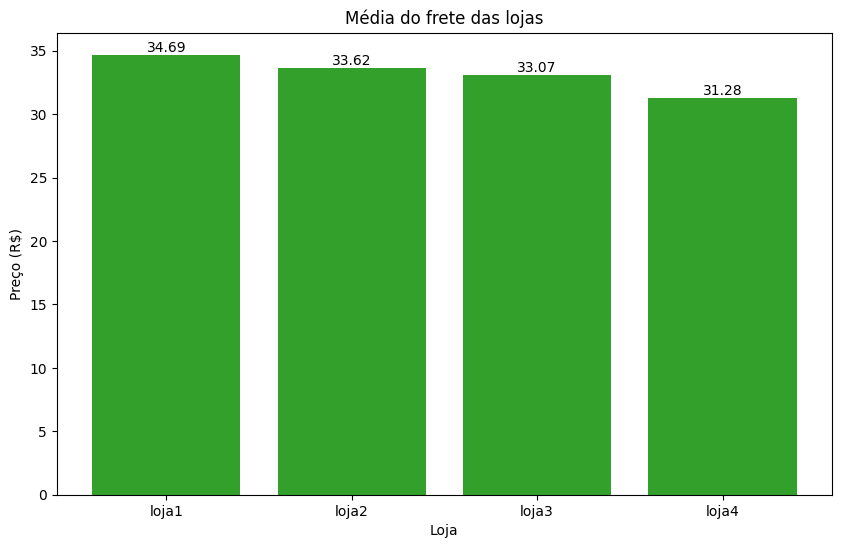

In [75]:
media_frete_loja1 = loja['Frete'].mean()
media_frete_loja2 = loja2['Frete'].mean()
media_frete_loja3 = loja3['Frete'].mean()
media_frete_loja4 = loja4['Frete'].mean()



media_frete_lojas = [media_frete_loja1, media_frete_loja2, media_frete_loja3, media_frete_loja4]

lojas = ['loja1', 'loja2', 'loja3', 'loja4']

plt.figure(figsize=(10, 6))
medias = plt.bar(lojas, media_frete_lojas, color = paleta[3])
plt.bar_label(medias, [f'{m:.2f}' for m in media_frete_lojas])
plt.title('Média do frete das lojas')
plt.xlabel('Loja')
plt.ylabel('Preço (R$)')
plt.show()

## Relatório Final

A análise em questão foi iniciada com o obejtivo de analisar os dados de quatro lojas e a partir das informações obtidas, decidir qual das lojas deve ser vendida, para isso, analisei a base de dados dessas quatro lojas e plotei os gráficos necessários para essa análise.

As quatro lojas tem praticamente o mesmo número de registros, o que torna essa comparação justa. Sendo assim, optamos por analisar 5 pontos:

  - O faturamento total das lojas.

  - As categorias de produtos mais e menos vendidas.

  - A média das avaliações de clientes por loja.

  - Os produtos mais e menos vendidos.

  - O frete médio de cada loja.

A partir desses gráficos foi possível obsservar um comportamento semelhante das lojas nos seguintes pontos: categorias de produtos mais e menos vendidas, em que, a categoria mais vendida em todas as lojas foi a de eletrônicos, o que varia é a categoria menos vendida, no entanto, a proximidade percentual entre as categorias é considerável, como pode ser observado na imagem a seguir:

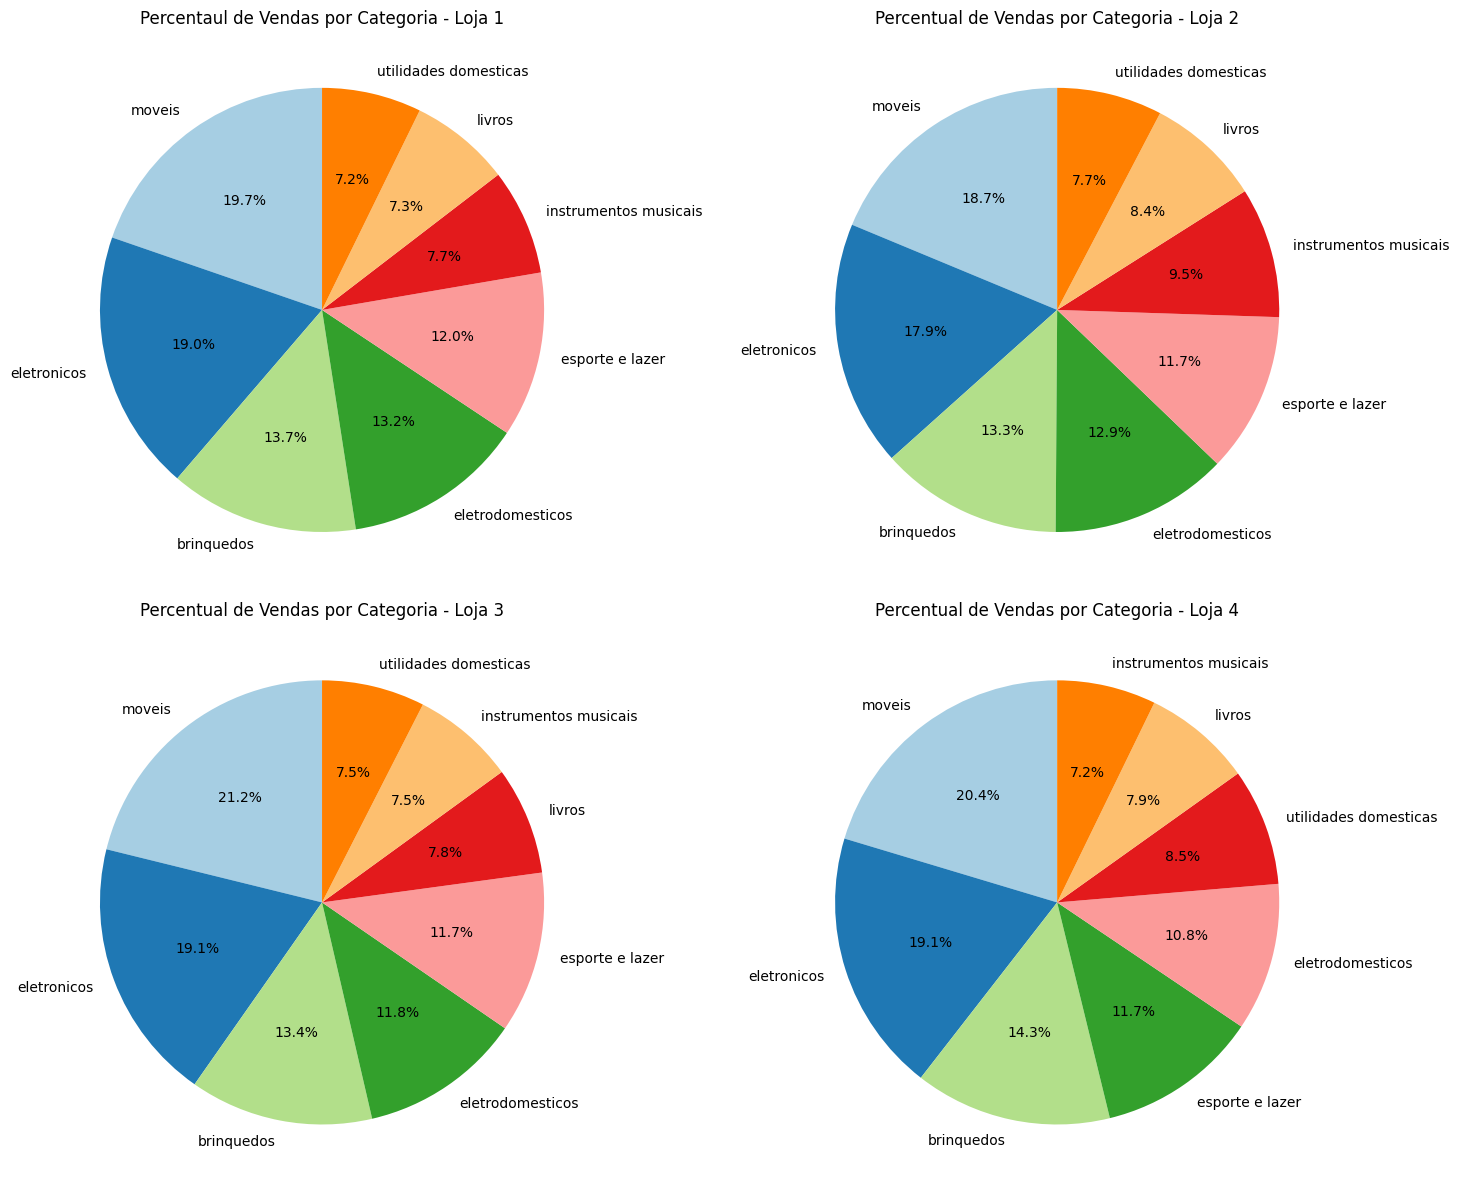

Outro comportamento semelhante é nas médias das avaliações dos clientes, nessas análises todas as lojas tiveram um comportamento muito parecido. O frete também é muito similar em todas as lojas, no entanto a loja 4 tem um frete ligeiramente mais barato que as demais.

Os produtos mais e menos vendidos variam em todas as lojas, o que é um comportamento comum, que para uma análise mais profunda, deveríamos levar em conta a localidade da loja, o público alvo e outros fatores.

No entanto, teve uma análise que trouxe dados mais interessantes para a análise, que foi o faturamento, as lojas 2 e 3 tem uma proximidade maior neste quesito, porém, quando comparamos as lojas 1 e 4 vemos uma distância de quase 150 mil reais, o que mostra que a loja 1 fatura mais que a loja 4, isso pode ser observado na seguinte imagem:

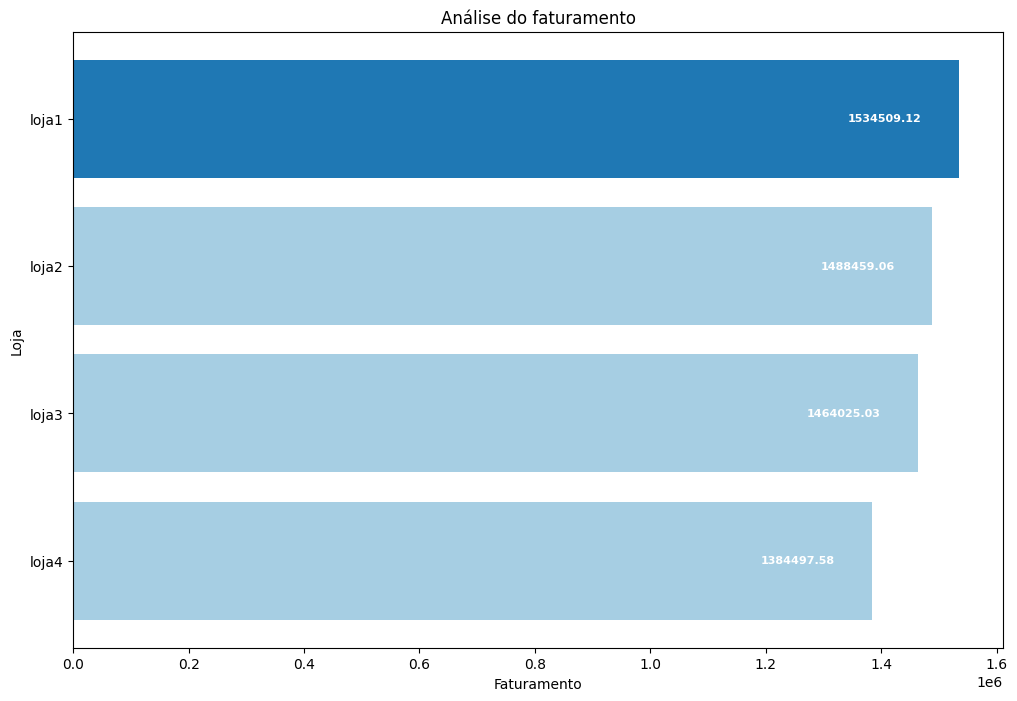

De acordo com o que foi dito e observado cheguei a conclusão que a loja vendida deveria ser a loja 4, uma vez que possui o menor faturamento e seus outros indicadores não trazem valores suficientemente bons para sustentar sua permanência.